# Milestone 1: Data Collection & Preprocessing

Import Libraries

In [1]:
import pandas as pd
import re
import nltk
import emoji
import seaborn as sns
import matplotlib.pyplot as plt 
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.util import ngrams
from textblob import TextBlob

Load Dataset

In [2]:
columns = [
    "sentiment",
    "id",
    "date",
    "query",
    "user",
    "text"
]

df = pd.read_csv(
    "training.csv",
    encoding="latin-1",
    names=columns
)

print(df.head())

   sentiment          id                          date     query  \
0          0  1467810369  Mon Apr 06 22:19:45 PDT 2009  NO_QUERY   
1          0  1467810672  Mon Apr 06 22:19:49 PDT 2009  NO_QUERY   
2          0  1467810917  Mon Apr 06 22:19:53 PDT 2009  NO_QUERY   
3          0  1467811184  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   
4          0  1467811193  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   

              user                                               text  
0  _TheSpecialOne_  @switchfoot http://twitpic.com/2y1zl - Awww, t...  
1    scotthamilton  is upset that he can't update his Facebook by ...  
2         mattycus  @Kenichan I dived many times for the ball. Man...  
3          ElleCTF    my whole body feels itchy and like its on fire   
4           Karoli  @nationwideclass no, it's not behaving at all....  


In [3]:

pos_val = 4 if 4 in df['sentiment'].values else 'positive'
neg_val = 0 if 0 in df['sentiment'].values else 'negative'


df_pos = df[df["sentiment"] == pos_val].sample(25000, random_state=42)
df_neg = df[df["sentiment"] == neg_val].sample(25000, random_state=42)


df = pd.concat([df_pos, df_neg])


df["sentiment"] = df["sentiment"].replace({0: "negative", 4: "positive"})


df = df.sample(frac=1, random_state=42).reset_index(drop=True)


print("تم تصغير الداتا بنجاح!")
print(df["sentiment"].value_counts())

تم تصغير الداتا بنجاح!
sentiment
negative    25000
positive    25000
Name: count, dtype: int64


Data Preprocessing

In [4]:
df.shape

(50000, 6)

In [5]:
df.columns = df.columns.str.strip()

In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sentiment  50000 non-null  object
 1   id         50000 non-null  int64 
 2   date       50000 non-null  object
 3   query      50000 non-null  object
 4   user       50000 non-null  object
 5   text       50000 non-null  object
dtypes: int64(1), object(5)
memory usage: 2.3+ MB
None


In [7]:
print(df.isnull().sum())

sentiment    0
id           0
date         0
query        0
user         0
text         0
dtype: int64


In [8]:
print(df.duplicated().sum())

0


In [9]:
df.drop_duplicates(inplace=True)
print(df.shape)

(50000, 6)


In [10]:
df["sentiment"] = df["sentiment"].replace({
    0: "negative",
    4: "positive"
})

print(df.head())

  sentiment          id                          date     query  \
0  negative  2244461844  Fri Jun 19 14:46:38 PDT 2009  NO_QUERY   
1  positive  1990768316  Mon Jun 01 05:41:51 PDT 2009  NO_QUERY   
2  positive  2068135312  Sun Jun 07 13:33:34 PDT 2009  NO_QUERY   
3  positive  1993993680  Mon Jun 01 11:14:46 PDT 2009  NO_QUERY   
4  negative  1564135132  Mon Apr 20 01:57:21 PDT 2009  NO_QUERY   

             user                                               text  
0     Shannon_Kai  weekend yet?????????????????????  work is kill...  
1    cleaninggirl  @1critic lol no problems bb glad to of shed so...  
2         Marston  @bhaugh Hrm, happy &quot;10,000 days old&quot;...  
3  TennantFanGirl              EPSOM DERBY DAY- SATURDAY! BE THERE!   
4        Toniilou  is not a fan of getting things disconnected an...  


2.	Data Exploration (EDA)

sentiment
negative    25000
positive    25000
Name: count, dtype: int64


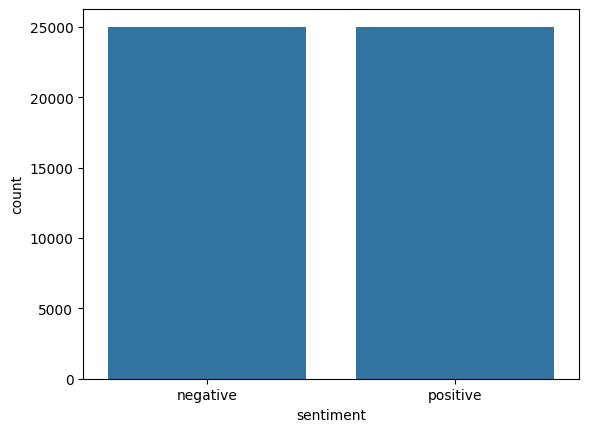

In [11]:
print(df['sentiment'].value_counts())
sns.countplot(x='sentiment', data=df)
plt.show()

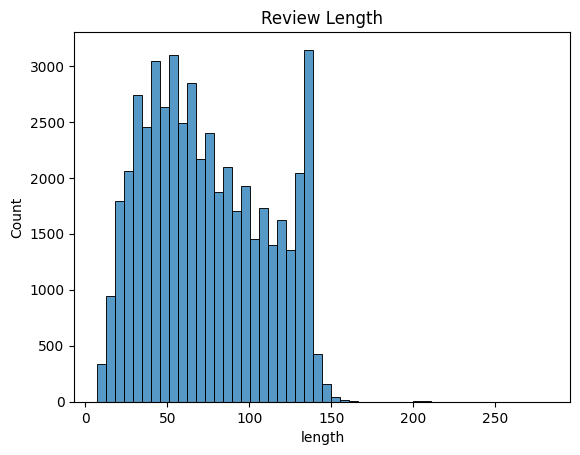

In [12]:

df['length'] = df['text'].apply(len)

# 2. رسم الهيستوجرام
sns.histplot(df['length'], bins=50)
plt.title('Review Length')
plt.show()

Download

In [13]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\LoQ\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LoQ\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# Milestone 2: Text preprocessing & Feature Engineering

Text Cleaning Function

In [14]:
def clean_text(text):
    text = str(text)

    # 1. HTML Tags
    text = re.sub(r'<.*?>', '', text)

    # 2. URLs 
    text = re.sub(r'http\S+|www\S+', '', text)

    # 3. Mentions & Hashtags 
    text = re.sub(r'@\S+|#\S+', '', text)

    # 4. Numbers 
    text = re.sub(r'\d+', '', text)

    # 5. Emojis
    text = emoji.replace_emoji(text, replace='')

    # 6. Punctuation & Special Characters 
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # 7. Lowercase
    text = text.lower()

    # 8. Extra Spaces 
    text = re.sub(r'\s+', ' ', text).strip()

    return text

Apply Cleaning

In [15]:
df['clean_text'] = df['text'].apply(clean_text)

Contraction Mapping

In [16]:
contractions = {
    "don't": "do not",
    "i'm": "i am",
    "you're": "you are",
    "can't": "cannot",
    "it's": "it is"
}

def expand_contractions(text):
    for key, value in contractions.items():
        text = text.replace(key, value)
    return text

In [17]:
df['clean_text'] = df['clean_text'].apply(expand_contractions)

Tokenization

Word Tokenization

In [18]:
df['tokens'] = df['clean_text'].apply(word_tokenize)

Sentence Tokenization

In [19]:
df['sentences'] = df['clean_text'].apply(sent_tokenize)

Stop Words Removal

In [20]:
stop_words = set(stopwords.words('english'))
def remove_stopwords(tokens):
    
    return [word for word in tokens if word not in stop_words]

df['filtered_tokens'] = df['tokens'].apply(remove_stopwords)

N-grams (Unigrams + Bigrams)

Unigrams

In [21]:
df['unigrams'] = df['filtered_tokens']

Bigrams

In [22]:
df['bigrams'] = df['filtered_tokens'].apply(lambda x: list(ngrams(x, 2)))

Final Output

In [23]:
df[['text', 'clean_text', 'filtered_tokens', 'bigrams']].head()

,text,clean_text,filtered_tokens,bigrams
0,weekend yet????????????????????? work is kill...,weekend yet work is killing me thanks new girl...,"[weekend, yet, work, killing, thanks, new, gir...","[(weekend, yet), (yet, work), (work, killing),..."
1,@1critic lol no problems bb glad to of shed so...,lol no problems bb glad to of shed some light ...,"[lol, problems, bb, glad, shed, light]","[(lol, problems), (problems, bb), (bb, glad), ..."
2,"@bhaugh Hrm, happy &quot;10,000 days old&quot;...",hrm happy quot days oldquot day,"[hrm, happy, quot, days, oldquot, day]","[(hrm, happy), (happy, quot), (quot, days), (d..."
3,EPSOM DERBY DAY- SATURDAY! BE THERE!,epsom derby day saturday be there,"[epsom, derby, day, saturday]","[(epsom, derby), (derby, day), (day, saturday)]"
4,is not a fan of getting things disconnected an...,is not a fan of getting things disconnected an...,"[fan, getting, things, disconnected, reconnect...","[(fan, getting), (getting, things), (things, d..."


feature engenering

In [24]:
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

from gensim.models import Word2Vec

In [25]:
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\LoQ\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\LoQ\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\LoQ\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

pos

In [26]:
def pos_tagging(tokens):

    return nltk.pos_tag(tokens)

df['pos_tags'] = df['filtered_tokens'].apply(pos_tagging)

df[['filtered_tokens', 'pos_tags']].head()

,filtered_tokens,pos_tags
0,"[weekend, yet, work, killing, thanks, new, gir...","[(weekend, NN), (yet, RB), (work, VB), (killin..."
1,"[lol, problems, bb, glad, shed, light]","[(lol, NN), (problems, NNS), (bb, VBP), (glad,..."
2,"[hrm, happy, quot, days, oldquot, day]","[(hrm, NN), (happy, JJ), (quot, NN), (days, NN..."
3,"[epsom, derby, day, saturday]","[(epsom, JJ), (derby, JJ), (day, NN), (saturda..."
4,"[fan, getting, things, disconnected, reconnect...","[(fan, NN), (getting, VBG), (things, NNS), (di..."


opinion_words

In [27]:
def extract_opinion_words(pos_tags):

    opinion_words = []

    for word, tag in pos_tags:

        if tag.startswith('JJ') or tag.startswith('RB'):
            opinion_words.append(word)

    return opinion_words

df['opinion_words'] = df['pos_tags'].apply(extract_opinion_words)

df[['clean_text', 'opinion_words']].head()

,clean_text,opinion_words
0,weekend yet work is killing me thanks new girl...,"[yet, new]"
1,lol no problems bb glad to of shed some light ...,[glad]
2,hrm happy quot days oldquot day,[happy]
3,epsom derby day saturday be there,"[epsom, derby]"
4,is not a fan of getting things disconnected an...,"[reconnected, nice]"


Sentiment Detection

In [28]:
def get_sentiment(text):

    polarity = TextBlob(text).sentiment.polarity

    if polarity >= 0:
        return "Positive"

    else:
        return "Negative"

Stemming

In [29]:
stemmer = PorterStemmer()

def stemming(tokens):

    return [stemmer.stem(word) for word in tokens]

df['stemmed'] = df['filtered_tokens'].apply(stemming)

df[['filtered_tokens', 'stemmed']].head()

,filtered_tokens,stemmed
0,"[weekend, yet, work, killing, thanks, new, gir...","[weekend, yet, work, kill, thank, new, girl, q..."
1,"[lol, problems, bb, glad, shed, light]","[lol, problem, bb, glad, shed, light]"
2,"[hrm, happy, quot, days, oldquot, day]","[hrm, happi, quot, day, oldquot, day]"
3,"[epsom, derby, day, saturday]","[epsom, derbi, day, saturday]"
4,"[fan, getting, things, disconnected, reconnect...","[fan, get, thing, disconnect, reconnect, nice,..."


Lemmatization

In [30]:
lemmatizer = WordNetLemmatizer()

def lemmatization(tokens):

    return [lemmatizer.lemmatize(word) for word in tokens]

df['lemmatized'] = df['filtered_tokens'].apply(lemmatization)

df[['filtered_tokens', 'lemmatized']].head()

,filtered_tokens,lemmatized
0,"[weekend, yet, work, killing, thanks, new, gir...","[weekend, yet, work, killing, thanks, new, gir..."
1,"[lol, problems, bb, glad, shed, light]","[lol, problem, bb, glad, shed, light]"
2,"[hrm, happy, quot, days, oldquot, day]","[hrm, happy, quot, day, oldquot, day]"
3,"[epsom, derby, day, saturday]","[epsom, derby, day, saturday]"
4,"[fan, getting, things, disconnected, reconnect...","[fan, getting, thing, disconnected, reconnecte..."


In [31]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import time

TF-IDF & train test split

In [32]:

tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(df['clean_text']) # تأكد إن clean_text هي اللي معمول لها Lemmatization
y = df['sentiment']


X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, 
    y, 
    test_size=0.2, 
    random_state=42
)

print(f"Feature Matrix Shape: {X_tfidf.shape}")

Feature Matrix Shape: (50000, 40196)


Naive Bayes Training & Evaluation

In [33]:
# Initialize Model
nb_model = MultinomialNB()

# Training
start_train = time.time()
nb_model.fit(X_train, y_train)
nb_train_time = time.time() - start_train

# Prediction
start_pred = time.time()
nb_preds = nb_model.predict(X_test)
nb_pred_time = time.time() - start_pred

# Results
print(f"Naive Bayes Accuracy: {accuracy_score(y_test, nb_preds):.4f}")
print(f"Training Time: {nb_train_time:.4f}s")
print(f"Prediction Time: {nb_pred_time:.4f}s")
print("\nClassification Report:\n", classification_report(y_test, nb_preds))

Naive Bayes Accuracy: 0.7539
Training Time: 0.0481s
Prediction Time: 0.0020s

Classification Report:
               precision    recall  f1-score   support

    negative       0.73      0.81      0.77      4972
    positive       0.79      0.70      0.74      5028

    accuracy                           0.75     10000
   macro avg       0.76      0.75      0.75     10000
weighted avg       0.76      0.75      0.75     10000



SVM Training & Evaluation

In [34]:
# Initialize Model (Linear kernel is usually best for text)
svm_model = SVC(kernel='linear', C=1.0)

# Training
start_train = time.time()
svm_model.fit(X_train, y_train)
svm_train_time = time.time() - start_train

# Prediction
start_pred = time.time()
svm_preds = svm_model.predict(X_test)
svm_pred_time = time.time() - start_pred

# Results
print(f"SVM Accuracy: {accuracy_score(y_test, svm_preds):.4f}")
print(f"Training Time: {svm_train_time:.4f}s")
print(f"Prediction Time: {svm_pred_time:.4f}s")
print("\nClassification Report:\n", classification_report(y_test, svm_preds))

SVM Accuracy: 0.7721
Training Time: 216.6704s
Prediction Time: 19.1876s

Classification Report:
               precision    recall  f1-score   support

    negative       0.77      0.77      0.77      4972
    positive       0.77      0.78      0.77      5028

    accuracy                           0.77     10000
   macro avg       0.77      0.77      0.77     10000
weighted avg       0.77      0.77      0.77     10000



Accuracy & Training Time & Prediction Time

In [35]:
# إنشاء الجدول باستخدام الأسماء التعريفية الصحيحة من الخطوات السابقة
comparison_data = {
    'Model': ['Naive Bayes', 'SVM'],
    
    # تأكد إن دي نفس الأسماء اللي في الـ print اللي فات
    'Accuracy': [
        accuracy_score(y_test, nb_preds), 
        accuracy_score(y_test, svm_preds)
    ],
    
    'Training Time (s)': [
        nb_train_time, 
        svm_train_time
    ],
    
    'Prediction Time (s)': [
        nb_pred_time, 
        svm_pred_time
    ]
}

comparison_df = pd.DataFrame(comparison_data)

# عرض الجدول
print("--- Baseline Models Performance Analysis ---")
display(comparison_df)

--- Baseline Models Performance Analysis ---


,Model,Accuracy,Training Time (s),Prediction Time (s)
0,Naive Bayes,0.7539,0.048086,0.002001
1,SVM,0.7721,216.670372,19.187556


Accuracy Comparison

(0.0, 1.0)

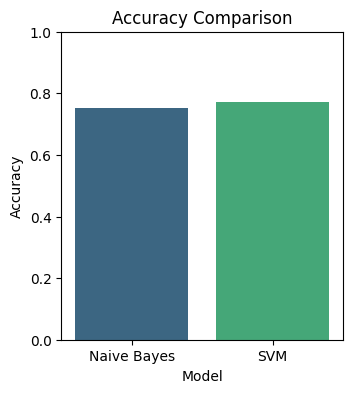

In [36]:
comparison_df = pd.DataFrame({
    'Model': ['Naive Bayes', 'SVM'],
    'Accuracy': [accuracy_score(y_test, nb_preds), accuracy_score(y_test, svm_preds)],
    'Prediction Time': [nb_train_time, svm_train_time]
})

# 2. رسم المقارنة بحجم 8x4
plt.figure(figsize=(8, 4))

# الرسمة الأولى: Accuracy
plt.subplot(1, 2, 1)
sns.barplot(x='Model', y='Accuracy', data=comparison_df, hue='Model', legend=False, palette='viridis')
plt.title("Accuracy Comparison")
plt.ylim(0, 1.0)




Visual Comparison (Confusion Matrix)

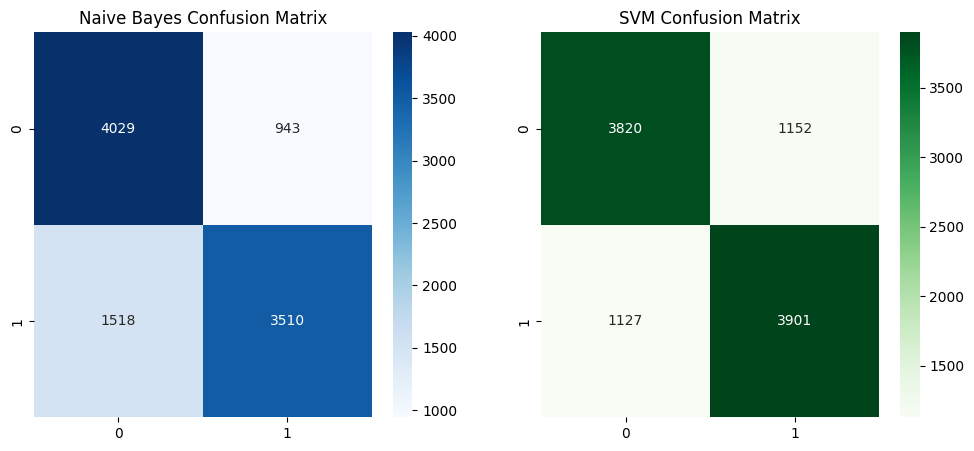

In [37]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))


sns.heatmap(confusion_matrix(y_test, nb_preds), annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Naive Bayes Confusion Matrix')


sns.heatmap(confusion_matrix(y_test, svm_preds), annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title('SVM Confusion Matrix')

plt.show()

In [38]:
def predict_sentiment(text):

    text_vector = tfidf.transform([text])

    prediction = svm_model.predict(text_vector)

    return prediction[0]

In [39]:
sample = "i play tennis"

result = predict_sentiment(sample)

print("Prediction:", result)

Prediction: positive


Bert

In [65]:
import pandas as pd
from datasets import Dataset
from sklearn.model_selection import train_test_split

# 1. تقسيم البيانات (تأكد أن df هو اسم الـ DataFrame بتاعك)
# بنحول الـ Sentiment لأرقام (0 و 1) فوراً عشان نخلص من الـ TypeError
df['sentiment'] = df['sentiment'].replace({'positive': 1, 'negative': 0}).astype(int)

train_df, test_df = train_test_split(df[['clean_text', 'sentiment']], test_size=0.2, random_state=42)

# 2. إعادة تسمية الأعمدة لـ text و label عشان BERT بيفهمهم كدة
train_df = train_df.rename(columns={'clean_text': 'text', 'sentiment': 'label'}).reset_index(drop=True)
test_df = test_df.rename(columns={'clean_text': 'text', 'sentiment': 'label'}).reset_index(drop=True)

# 3. تحويل لـ Dataset وتطبيق الـ Tokenizer
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

# 4. مسح عمود النص (الـ String) عشان الـ GPU ميبعبصش الدنيا
tokenized_train = tokenized_train.remove_columns(["text"])
tokenized_test = tokenized_test.remove_columns(["text"])

# 5. تحويل لـ PyTorch Tensors
tokenized_train.set_format("torch")
tokenized_test.set_format("torch")

print("Done! Data is ready for the GPU.")

Map: 100%|██████████| 10000/10000 [00:00<00:00, 29394.93 examples/s]

Done! Data is ready for the GPU.


In [67]:
import torch
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback
import numpy as np
from sklearn.metrics import accuracy_score

# 1. التأكد إن الموديل على الكارت
model.to("cuda")

# 2. دالة الحساب
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, predictions)}

# 3. إعدادات التدريب (تم تعديل الاسم لـ eval_strategy)
training_args = TrainingArguments(
    output_dir='./results',
    eval_strategy="epoch",       # الاسم الجديد المظبوط
    save_strategy="epoch",
    logging_strategy="epoch",    # عشان يطبع الـ Loss والـ Accuracy كل لفة
    learning_rate=2e-5,
    per_device_train_batch_size=16, 
    num_train_epochs=5,              
    fp16=True,                   # قوة الـ RTX 3050 في الـ Mixed Precision
    load_best_model_at_end=True,     
    metric_for_best_model="accuracy",
    report_to="none"                 
)

# 4. بناء الـ Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train, # تأكد إن ده اسم الـ dataset اللي جهزناه
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)] 
)

# ابدأ الملحمة وشوف الجدول دلوقتي
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.447300,0.412128,0.813300
2,0.333188,0.420834,0.814800
3,0.230963,0.543203,0.812600
4,0.162025,0.728953,0.811600


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.36it/s]


TrainOutput(global_step=10000, training_loss=0.2933691589355469, metrics={'train_runtime': 1132.1302, 'train_samples_per_second': 176.658, 'train_steps_per_second': 11.041, 'total_flos': 5298695946240000.0, 'train_loss': 0.2933691589355469, 'epoch': 4.0})

In [68]:
# تقييم الموديل النهائي
results = trainer.evaluate()
print(f"DistilBERT Final Validation Accuracy: {results['eval_accuracy']:.4f}")

# كدة تقدر تضيف الرقم ده للجدول بتاع Naive Bayes و SVM اللي عملناه

Training Loss,Validation Loss,Epoch,Accuracy
0.162025,0.420834,4,0.814800


DistilBERT Final Validation Accuracy: 0.8148


In [69]:
# حفظ الموديل والـ Tokenizer بعد التدريب
model.save_pretrained("./my_best_model")
tokenizer.save_pretrained("./my_best_model")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.53it/s]


('./my_best_model\\tokenizer_config.json', './my_best_model\\tokenizer.json')